# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

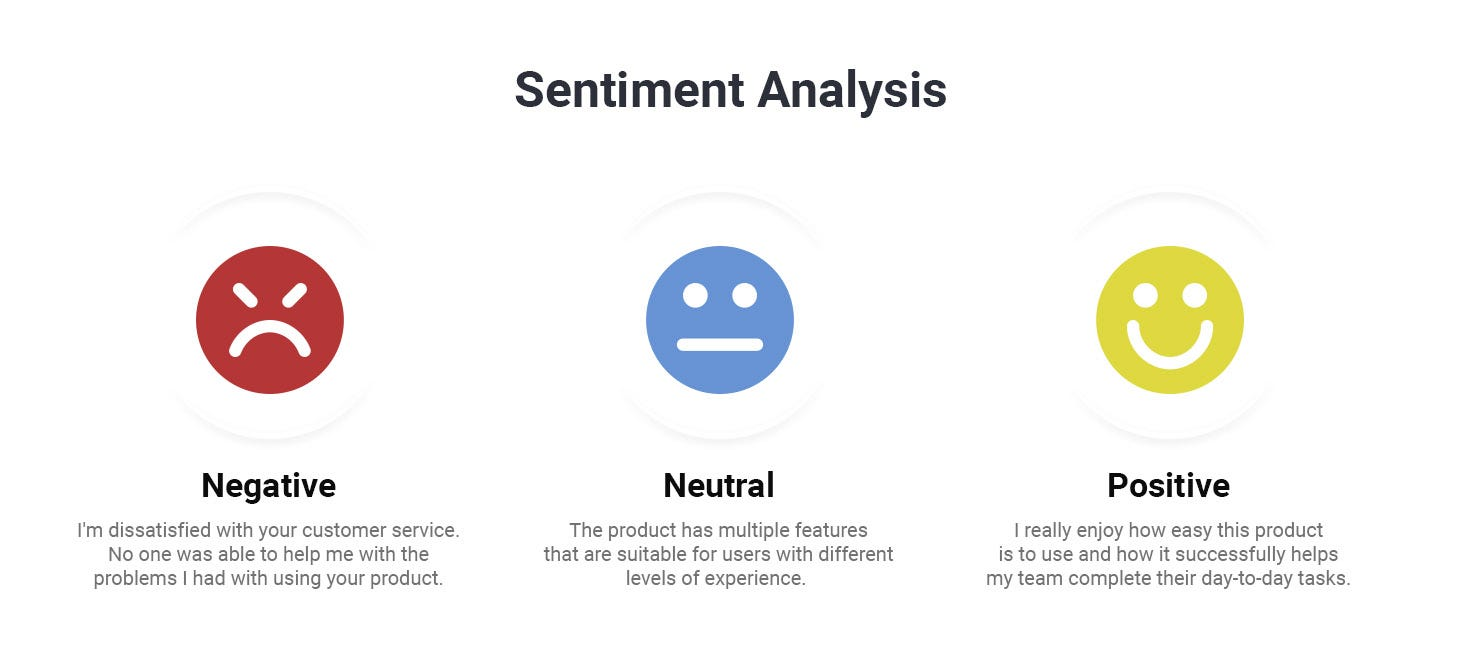

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [ ]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [1]:
%pip install -q pandas scikit-learn matplotlib kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Task 1: Load Amazon phone reviews and perform FIVE text preprocessing steps.
import re
from pathlib import Path
import pandas as pd

# If you downloaded the Kaggle CSV yourself, optionally set its exact path here:
DATASET_CSV = None  # e.g. r"C:\Users\abdul\Downloads\Amazon_Unlocked_Mobile.csv"

def choose_amazon_csv(folder):
    """Find the Amazon reviews CSV, not an unrelated CSV in the same folder."""
    folder = Path(folder)
    if not folder.exists():
        return None
    for path in sorted(folder.rglob("*.csv")):
        try:
            cols = pd.read_csv(path, nrows=0, encoding="utf-8").columns
            if {"Reviews", "Rating"}.issubset(cols):
                return path
        except (OSError, UnicodeError, pd.errors.ParserError):
            continue
    return None

if DATASET_CSV:
    csv_path = Path(DATASET_CSV).expanduser()
    if not csv_path.is_file():
        raise FileNotFoundError(f"CSV not found: {csv_path}")
else:
    # Prefer an already downloaded CSV; don't require downloading it twice.
    csv_path = choose_amazon_csv(Path.cwd())
    if csv_path is None:
        csv_path = choose_amazon_csv(Path.home() / "Downloads")
    if csv_path is None:
        import kagglehub
        try:
            dataset_dir = kagglehub.dataset_download(
                "PromptCloudHQ/amazon-reviews-unlocked-mobile-phones"
            )
        except Exception as exc:
            raise RuntimeError(
                "Kaggle download failed. Download the CSV from the dataset link "
                "above, then set DATASET_CSV to its complete local path."
            ) from exc
        csv_path = choose_amazon_csv(dataset_dir)
    if csv_path is None:
        raise FileNotFoundError(
            "No CSV with Reviews and Rating columns was found. "
            "Set DATASET_CSV to the Amazon reviews CSV path."
        )

print("Dataset file:", csv_path)
data = pd.read_csv(csv_path, usecols=["Reviews", "Rating"], encoding="utf-8",
                   on_bad_lines="skip")
data["Rating"] = pd.to_numeric(data["Rating"], errors="coerce")
data = data.dropna(subset=["Reviews", "Rating"]).copy()
data = data[data["Rating"].between(1, 5)]

# The same three sentiment classes used in the Disneyland example:
# Ratings 1-2: negative; 3: neutral; 4-5: positive.
data["Sentiment"] = data["Rating"].map(
    lambda r: "negative" if r < 3 else ("neutral" if r == 3 else "positive")
)

def preprocess_text(text):
    text = str(text).lower()                 # 1. Lowercase
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # 2. Remove URLs
    text = re.sub(r"<[^>]*>", " ", text)   # 3. Remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)  # 4. Remove digits/punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()  # 5. Normalize whitespace
    return text

data["Cleaned_Review"] = data["Reviews"].map(preprocess_text)
data = data[data["Cleaned_Review"].str.len() > 0].copy()

# Keep runtime manageable on laptops; set None to use the entire cleaned dataset.
MAX_ROWS = 100_000
if MAX_ROWS is not None and len(data) > MAX_ROWS:
    data = data.sample(n=MAX_ROWS, random_state=42).copy()

print("Reviews after cleaning:", len(data))
print("Sentiment counts:\n", data["Sentiment"].value_counts().to_string())
print("\nSample cleaned reviews:\n", data[["Cleaned_Review", "Sentiment"]].head().to_string(index=False))


Dataset file: C:\Users\abdul\Downloads\Amazon Sentiment Analyzer\Amazon Sentiment Analyzer\My_data.csv
Reviews after cleaning: 3419
Sentiment counts:
 Sentiment
positive    2698
negative     508
neutral      213

Sample cleaned reviews:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      Cleaned_Review Sentiment
                                                                            

In [4]:
# Task 2: Train/test split (80/20, reproducible and stratified by sentiment).
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data["Cleaned_Review"], data["Sentiment"],
    test_size=0.20, random_state=42, stratify=data["Sentiment"]
)
print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))


Training reviews: 2735
Testing reviews: 684


In [5]:
# Task 3: TF-IDF feature extraction. Fit ONLY on training texts to prevent data leakage.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print("Training TF-IDF matrix:", X_train_tfidf.shape)
print("Testing TF-IDF matrix:", X_test_tfidf.shape)


Training TF-IDF matrix: (2735, 2718)
Testing TF-IDF matrix: (684, 2718)


In [6]:
# Task 4: Train a Multinomial Naive Bayes classifier.
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB(alpha=1.0)
nb_classifier.fit(X_train_tfidf, y_train)
print("Naive Bayes model trained successfully.")


Naive Bayes model trained successfully.


In [7]:
# Task 5: Evaluate the trained model on the held-out TEST set.
from sklearn.metrics import accuracy_score, classification_report

predictions = nb_classifier.predict(X_test_tfidf)
labels = ["negative", "neutral", "positive"]
print(f"Test accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, predictions, labels=labels, zero_division=0))


Test accuracy: 0.7924

Classification report:

              precision    recall  f1-score   support

    negative       1.00      0.02      0.04       102
     neutral       0.00      0.00      0.00        42
    positive       0.79      1.00      0.88       540

    accuracy                           0.79       684
   macro avg       0.60      0.34      0.31       684
weighted avg       0.77      0.79      0.70       684



Confusion matrix (rows: actual; columns: predicted):
          negative  neutral  positive
negative         2        0       100
neutral          0        0        42
positive         0        0       540


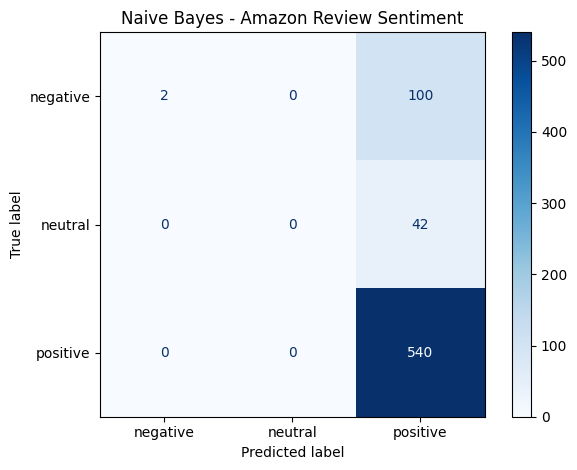

In [8]:
# Task 6: Print and visualize the confusion matrix (rows=true, columns=predicted).
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions, labels=labels)
print("Confusion matrix (rows: actual; columns: predicted):")
print(pd.DataFrame(cm, index=labels, columns=labels))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap="Blues", values_format="d"
)
plt.title("Naive Bayes - Amazon Review Sentiment")
plt.tight_layout()
plt.show()
